 The Goal: Build a machine learning model that predicts whether a customer will churn (Yes/No). This is called a classification problem.
 
 Data: You have a dataset where:
 Features (X): Customer information (tenure, monthly charges, contract type, etc.)
 Target (y): Whether they churned (Yes = 1, No = 0)
 
 The Process:
    1. Split data into training and testing sets
    2. Train a model on the training data
    3. Evaluate how well it performs on the testing data
    4. Compare different models to find the best one

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models to try
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# For handling warnings (optional)
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load The Processed Data 
# Load the features and target you saved earlier
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()  # Convert to 1D array

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Features shape: (7043, 30)
Target shape: (7043,)
Churn rate: 26.5%


Split Data for Training and Testing

In [3]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintains the same churn ratio in both sets
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training churn rate: {y_train.mean()*100:.1f}%")
print(f"Testing churn rate: {y_test.mean()*100:.1f}%")

Training set: 5634 samples
Testing set: 1409 samples
Training churn rate: 26.5%
Testing churn rate: 26.5%


Train and Evaluate Multiple Models
try three different models to see which performs best. Think of this as taste-testing different recipes.

Model 1: Logistic Regression (The Baseline)

In [4]:
# Create and train the model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Make predictions
y_pred_logreg = logreg.predict(X_test)

# Evaluate
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {accuracy_logreg*100:.2f}%")

Logistic Regression Accuracy: 80.41%


Model 2: Decision Tree (Interpretable but Prone to Overfitting)

In [5]:
# Create and train the model
dtree = DecisionTreeClassifier(random_state=42, max_depth=5)  # Limit depth to avoid overfitting
dtree.fit(X_train, y_train)

# Make predictions
y_pred_dtree = dtree.predict(X_test)

# Evaluate
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
print(f"Decision Tree Accuracy: {accuracy_dtree*100:.2f}%")

Decision Tree Accuracy: 79.42%


Model 3: Random Forest (The Powerhouse)

In [6]:
# Create and train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf*100:.2f}%")

Random Forest Accuracy: 81.05%


Compare and Visualize Results

                 Model   Accuracy
2        Random Forest  81.050390
0  Logistic Regression  80.411639
1        Decision Tree  79.418027


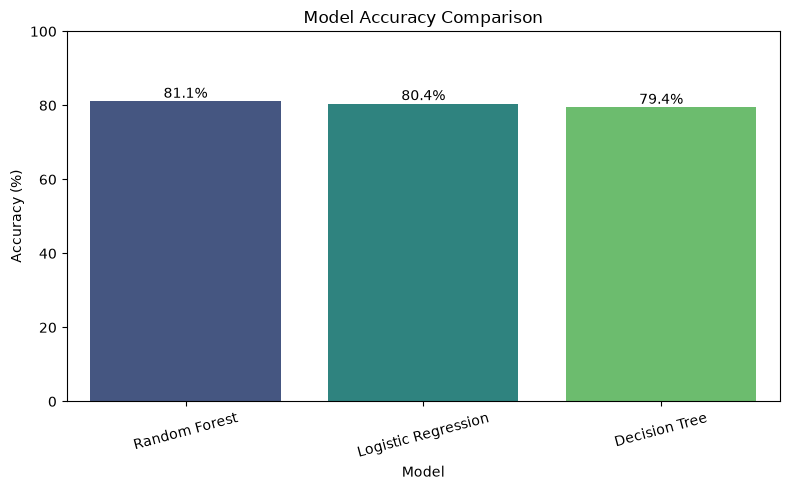

In [7]:
# Create a comparison DataFrame
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_logreg, accuracy_dtree, accuracy_rf]
})

# Sort by accuracy
results = results.sort_values('Accuracy', ascending=False)
results['Accuracy'] = results['Accuracy'] * 100
print(results)

# Plot the comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)

# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Get Deeper Insights (Confusion Matrix)
A confusion matrix shows you exactly where your model is making mistakes.

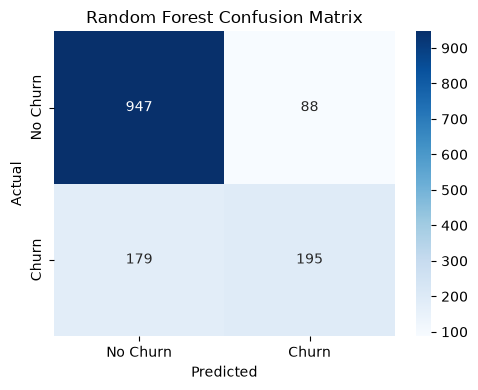

Random Forest Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.88      1035
       Churn       0.69      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [8]:
# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'], 
                yticklabels=['No Churn', 'Churn'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Plot confusion matrix for the best model (Random Forest)
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix')

# Print detailed classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Feature Importance (What Matters Most?)
Random Forest can tell us which features were most important for making predictions.

Top 10 Most Important Features:
                                 Feature  Importance
1                                 tenure    0.208987
3                           TotalCharges    0.138127
2                         MonthlyCharges    0.092948
10           InternetService_Fiber optic    0.085420
28        PaymentMethod_Electronic check    0.074104
25                     Contract_Two year    0.069807
13                    OnlineSecurity_Yes    0.041097
24                     Contract_One year    0.039512
19                       TechSupport_Yes    0.026201
16  DeviceProtection_No internet service    0.022639


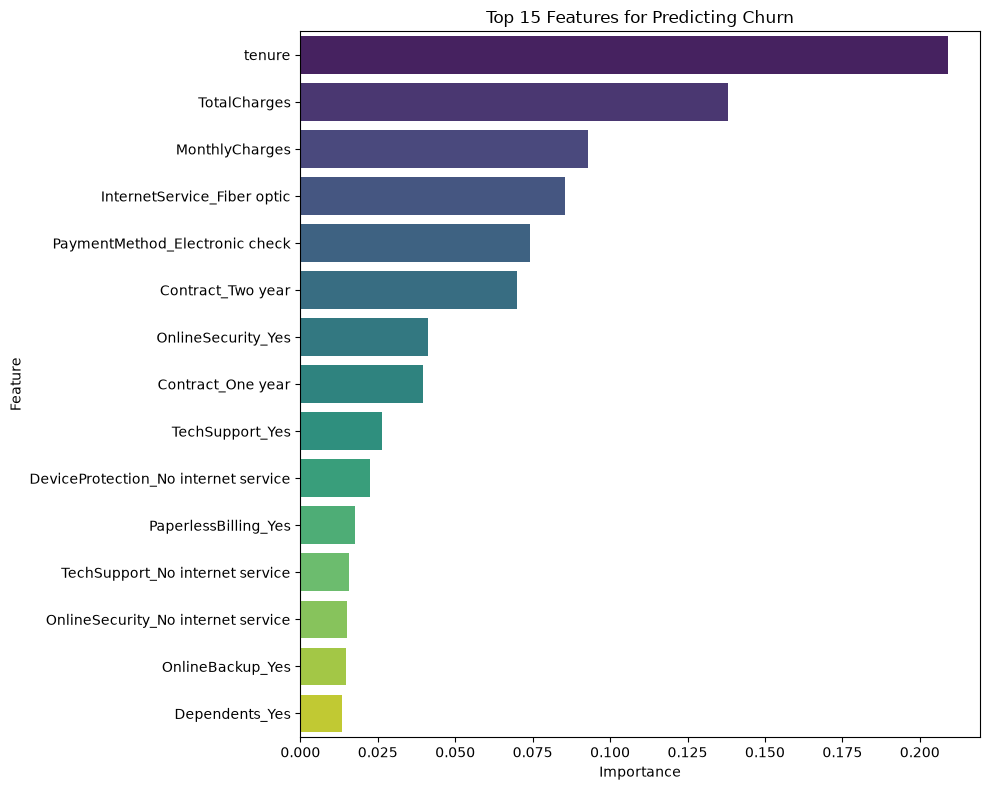

In [9]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top 10 most important features
print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Features for Predicting Churn')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

Interpret Results (The "So What?")
Let's translate these numbers into business insights.

In [10]:
# 1. What's the overall churn rate?
overall_churn_rate = y.mean() * 100
print(f"Overall Churn Rate: {overall_churn_rate:.1f}%")

# 2. How well does our model do at identifying at-risk customers?
# Let's use the Random Forest model (our best so far)
churn_predicted = rf.predict(X)
churn_risk_percentage = churn_predicted.mean() * 100
print(f"Percentage of customers predicted to churn: {churn_risk_percentage:.1f}%")

# 3. Which features are most important?
print("\nTop 3 Churn Predictors:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']*100:.1f}% importance")

Overall Churn Rate: 26.5%
Percentage of customers predicted to churn: 20.2%

Top 3 Churn Predictors:
  - tenure: 20.9% importance
  - TotalCharges: 13.8% importance
  - MonthlyCharges: 9.3% importance
